# Trabajo Práctico 2 (TP2) - Parte 2: Regresión Logística, Curva de Aprendizaje y Evaluación de Desempeño

### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 2
1. Configurar una partición estratificada Train/Test (80% Train, 20% Test sobre 64,295 muestras) previniendo el fuga de datos (*data leakage*).
2. Diseñar un `ColumnTransformer` profesional con `SimpleImputer`, `PolynomialFeatures(degree=2)`, `StandardScaler` y `OneHotEncoder`.
3. Entrenar un modelo de `LogisticRegression(class_weight='balanced')` con optimización de hiperparámetros vía `GridSearchCV`.
4. Calcular y graficar la **Curva de Aprendizaje (`learning_curve`)** evaluando la convergencia en validación cruzada.
5. Optimizar el umbral de decisión ($	au^*$) e inspeccionar la Matriz de Confusión, Curva ROC (AUC) y Curva Precision-Recall.


In [2]:
# 1. Carga de Librerías y Dataset del TP2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'reglamento_nuevo_unificado.csv'
df_raw = pd.read_csv(csv_path)
print(f"Dataset del TP2 cargado exitosamente: {df_raw.shape[0]:,} filas.")
#Carga del Dataset Clean creado en la parte 1
df_clean= pd.read_csv('reglamento_dfclean.csv')

Dataset del TP2 cargado exitosamente: 64,295 filas.


## Ejercicio 1: Partición Estratificada Train / Test

Define las listas de atributos numéricos `num_features` y categóricos `cat_features`.
Realiza una partición estratificada del 80% para entrenamiento (`X_train`) y 20% para prueba (`X_test`).


In [3]:
# TODO: Definir num_features, cat_features y particionar X e y
# === ESCRIBE TU CÓDIGO AQUÍ ===
num_features = ['Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 'FirmaCalc_Clean', 'Asis_Clean']
cat_features = ['Carrera_Nombre', 'Semestre']
X = df_clean[num_features + cat_features]
#Para que tome de forma correcta
y = (df_clean['Aprobado'] == 'S').astype(int)
# Suponiendo df_clean cargado del notebook anterior
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Ejercicio 2: Construcción del Preprocesador Profesional (`ColumnTransformer`)

Construye un `Pipeline` numérico con:
1. `SimpleImputer(strategy='median')`
2. `PolynomialFeatures(degree=2, include_bias=False)`
3. `StandardScaler()`

Y un `Pipeline` categórico con `SimpleImputer` y `OneHotEncoder(handle_unknown='ignore')`.


In [4]:
# TODO: Ensamblar num_transformer, cat_transformer y preprocessor
# === ESCRIBE TU CÓDIGO AQUÍ ===
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])



## Ejercicio 3: Entrenamiento del Modelo y Búsqueda en Malla (`GridSearchCV`)

Ensambla `full_pipeline` con `LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=2000)`.
Configura `GridSearchCV` sobre el parámetro de regularización `C` en `[0.01, 0.1, 1.0, 10.0]` con `scoring='f1'`.


In [5]:
# TODO: Instanciar full_pipeline y GridSearchCV
from sklearn.metrics import make_scorer
# === ESCRIBE TU CÓDIGO AQUÍ ===
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42, class_weight='balanced'))
])

param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}
grid_search = GridSearchCV(full_pipeline, param_grid, cv=StratifiedKFold(n_splits=5), scoring='f1', n_jobs=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_


## Ejercicio 4: Graficación de la Curva de Aprendizaje (`learning_curve`)

Calcula y grafica la curva de aprendizaje utilizando `learning_curve` sobre `X_train` y `y_train` con 10 tamaños de entrenamiento (`np.linspace(0.1, 1.0, 10)`).


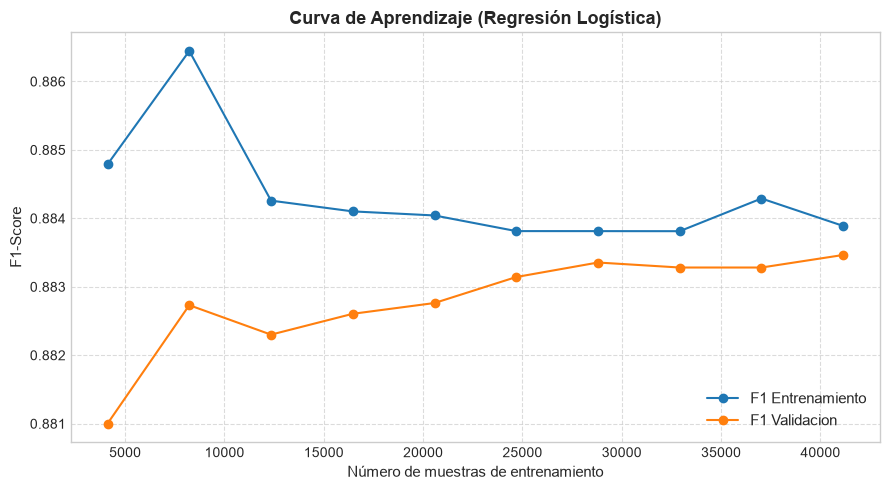

In [6]:
# TODO: Calcular y graficar la Curva de Aprendizaje (Learning Curve)
# === ESCRIBE TU CÓDIGO AQUÍ ===
train_sizes, train_scores, val_scores = learning_curve(
     best_model, X_train, y_train, cv=StratifiedKFold(n_splits=5),
     scoring='f1', train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=1
 )
#promedios y desviacion estandar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean= np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)
#grafico
plt.figure(figsize=(9,5))
plt.plot(train_sizes,train_mean,'o-',color='tab:blue',label='F1 Entrenamiento')
plt.plot(train_sizes,val_mean,'o-',color='tab:orange',label='F1 Validacion')
plt.title('Curva de Aprendizaje (Regresión Logística)', fontsize=13, fontweight='bold')
plt.xlabel('Número de muestras de entrenamiento', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Ejercicio 5: Optimización del Umbral de Decisión y Evaluación de Desempeño

En el conjunto de prueba (`X_test`):
1. Obtén las probabilidades de aprobación `y_proba_test`.
2. Optimiza el umbral de decisión ($	au^*$) entre `0.1` y `0.9` que maximiza el F1-Score.
3. Grafica la **Matriz de Confusión**, la **Curva ROC (AUC)** y la **Curva Precision-Recall**.


=== RESULTADOS DE EVALUACIÓN EN TEST ===
Umbral óptimo (tau*): 0.4100
F1-Score máximo: 0.8882
ROC AUC Score: 0.9334
Average Precision (AP): 0.9481

Reporte de Clasificación:
               precision    recall  f1-score   support

Reprobado (0)       0.86      0.77      0.81      5058
 Aprobado (1)       0.86      0.92      0.89      7801

     accuracy                           0.86     12859
    macro avg       0.86      0.84      0.85     12859
 weighted avg       0.86      0.86      0.86     12859



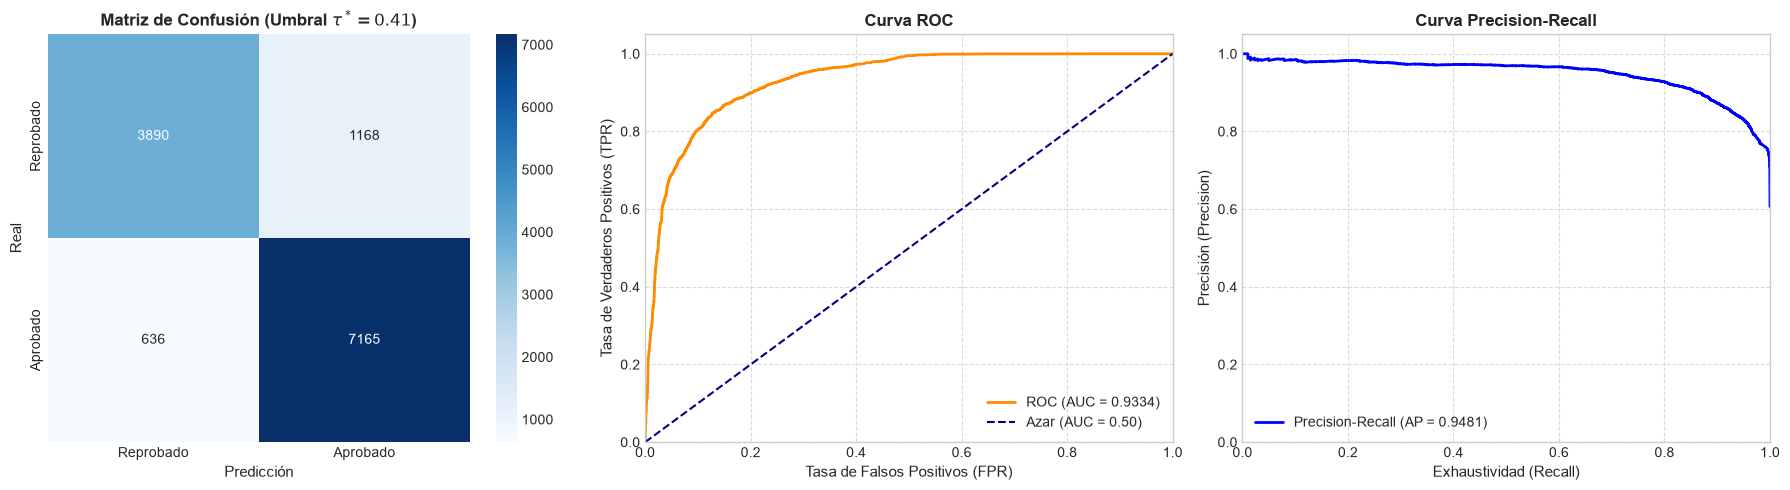

In [7]:
# TODO: Optimizar umbral y graficar métricas en Test
# === ESCRIBE TU CÓDIGO AQUÍ ===
# 1. Obtener probabilidades en el conjunto de test
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 2. Optimizar el umbral de decisión (tau*) entre 0.1 y 0.9 maximizando F1-Score
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_test, (y_proba_test >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Predicciones finales usando el umbral óptimo
y_pred = (y_proba_test >= best_thresh).astype(int)

# Métricas globales
auc_score = roc_auc_score(y_test, y_proba_test)
ap_score = average_precision_score(y_test, y_proba_test)

print(f"=== RESULTADOS DE EVALUACIÓN EN TEST ===")
print(f"Umbral óptimo (tau*): {best_thresh:.4f}")
print(f"F1-Score máximo: {best_f1:.4f}")
print(f"ROC AUC Score: {auc_score:.4f}")
print(f"Average Precision (AP): {ap_score:.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Reprobado (0)', 'Aprobado (1)']))

# 3. Graficación de Matriz de Confusión, Curva ROC y Curva Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Reprobado', 'Aprobado'],
            yticklabels=['Reprobado', 'Aprobado'])
axes[0].set_title(f'Matriz de Confusión (Umbral $\\tau^* = {best_thresh:.2f}$)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Real', fontsize=11)

# Subplot 2: Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Azar (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
axes[1].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.7)

# Subplot 3: Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
axes[2].plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall (AP = {ap_score:.4f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Exhaustividad (Recall)', fontsize=11)
axes[2].set_ylabel('Precisión (Precision)', fontsize=11)
axes[2].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[2].legend(loc='lower left', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()